In [56]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pywt
from skimage.transform import resize
import tensorflow.keras.backend as K
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

In [35]:

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        segment_list.append(SplitData)

        one_hot = np.zeros((segments, len(DataList)))
        one_hot[:, count] = 1
        one_hot_labels.append(one_hot)

        int_labels = np.full((segments, 1), count)
        integer_labels.append(int_labels)
        
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    # return X, LabelPositional, Label
    return segment_list, one_hot_labels, integer_labels

# Run preparation
# X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)



In [36]:
def generate_scalogram(segment, image_shape, fs=48000, scales=np.geomspace(1, 128), wavelet='cmor', log_scale=True, debug=False, label_name=None):
    coeffs, freqs = pywt.cwt(segment, scales, wavelet, sampling_period=1/fs)
    scalogram = np.log1p(np.abs(coeffs))
    # scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram))  # Normalize
    scalogram -= scalogram.min()
    scalogram /= scalogram.max()
    scalogram = resize(scalogram, image_shape, mode='constant', anti_aliasing=True)
    return scalogram



/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


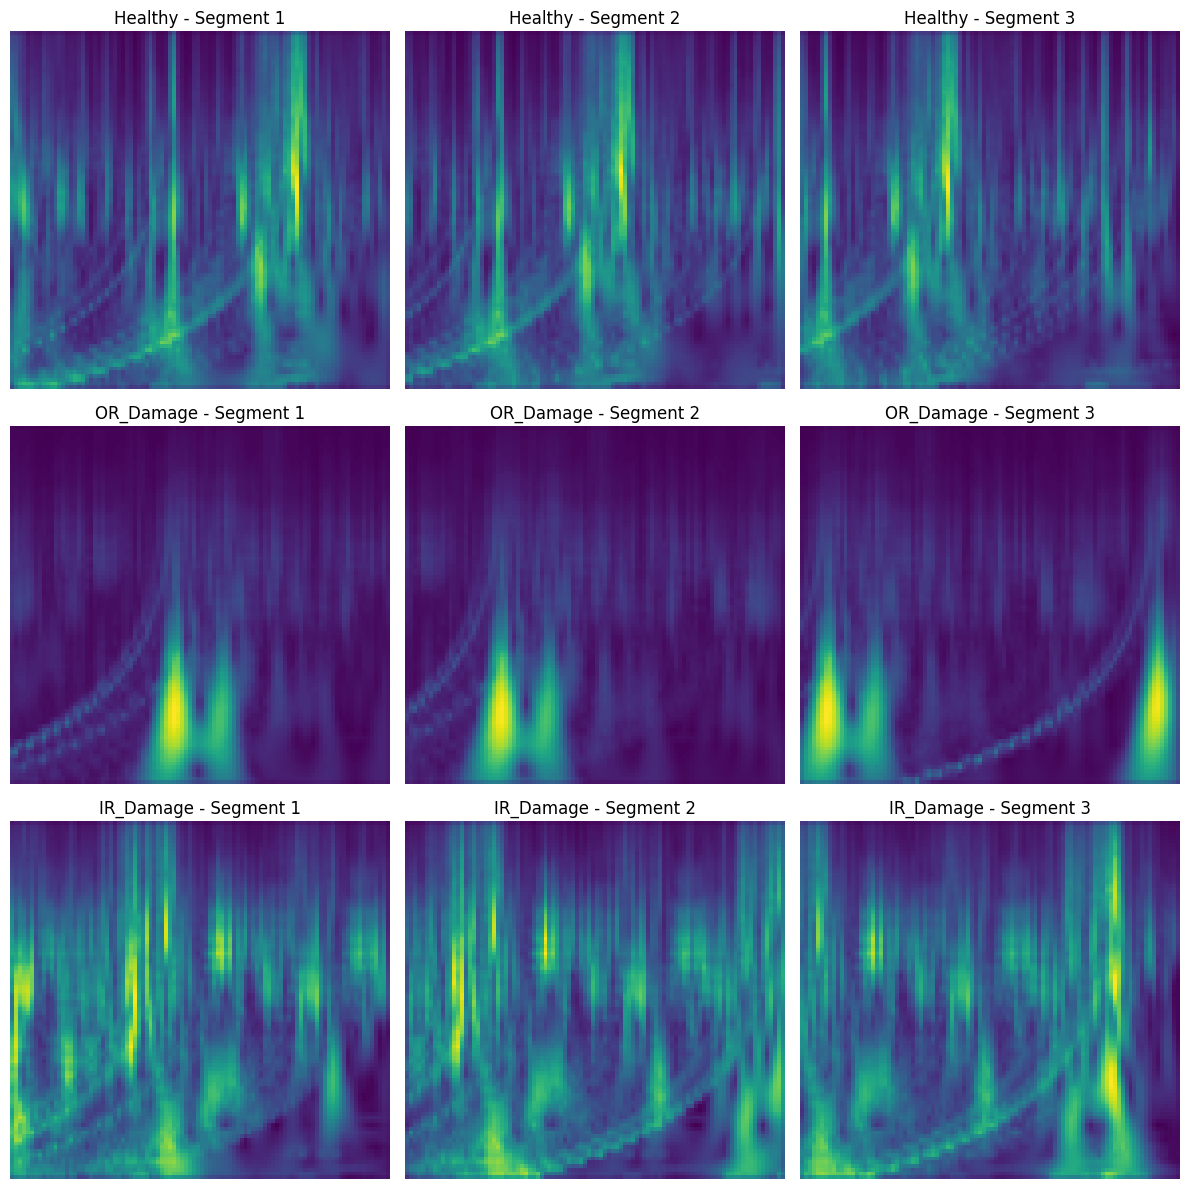

In [37]:

def plot_scalogram_grid(scalograms, titles, n_cols=3):
    n_rows = int(np.ceil(len(scalograms) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for idx, (scalogram, title) in enumerate(zip(scalograms, titles)):
        axes[idx].imshow(scalogram, aspect='auto', cmap='viridis')
        axes[idx].set_title(title)
        axes[idx].axis('off')
    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# Parameters
image_shape = (96, 96)
samples_per_block = 1600
interval_length = 290
num_samples_per_class = 3

# Sampling function
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

# Generate scalograms for each class
scalograms_to_plot = []
titles = []
for class_idx, signal_array in enumerate(grouped_signals[:3]):  # Only classes 0 to 2
    class_name = data_structure[class_idx][0]
    sampled_segments = Sampling(signal_array, interval_length, samples_per_block)
    for i in range(min(num_samples_per_class, len(sampled_segments))):
        scalogram = generate_scalogram(sampled_segments[i], image_shape=image_shape)
        scalograms_to_plot.append(scalogram)
        titles.append(f"{class_name} - Segment {i+1}")

# Plot
plot_scalogram_grid(scalograms_to_plot, titles)

In [38]:

# Updated per-file DataPreparation with time-based split
def process_each_mat_file_separately(data_structure, root_dir, interval_length, samples_per_block, train_ratio, sample_limit_per_label,image_shape):
    all_train_segments, all_test_segments = [], []
    all_train_labels_positional, all_test_labels_positional = [], []
    all_train_labels, all_test_labels = [], []
    segment_counts = {0: 0, 1: 0, 2: 0}
   
    
    for label, (label_name, folders) in data_structure.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                continue
            mat_path = os.path.join(folder_path, mat_files[0])
            df = extract_signals_df(mat_path)
            df = df.iloc[:sample_limit_per_label[label]].copy()
            signal = df["vibration"].values.flatten()

            # Sampling
            segments = Sampling(signal, interval_length, samples_per_block)

            scalograms = np.array([generate_scalogram(seg, image_shape, fs=48000) for seg in segments])
            
            segment_counts[label] += segments.shape[0]
            if segments.shape[0] == 0:
                continue
            n_segments = segments.shape[0]
            split_idx = int(n_segments * train_ratio)

            train_segments = scalograms[:split_idx]
            test_segments = scalograms[split_idx:]

            y_train_pos = np.zeros((train_segments.shape[0], len(data_structure)))
            y_train_pos[:, label] = 1
            y_train = np.full((train_segments.shape[0], 1), label)

            y_test_pos = np.zeros((test_segments.shape[0], len(data_structure)))
            y_test_pos[:, label] = 1
            y_test = np.full((test_segments.shape[0], 1), label)

            all_train_segments.append(train_segments)
            all_test_segments.append(test_segments)
            all_train_labels_positional.append(y_train_pos)
            all_test_labels_positional.append(y_test_pos)
            all_train_labels.append(y_train)
            all_test_labels.append(y_test)

    print("\nSegmented dataset shape:")
    for label in sorted(segment_counts.keys()):
        fault_label = data_structure[label][0]
        print(f"Class: {label} Fault Label: {fault_label} Segments: {segment_counts[label]} segments")
        
    # Final combine
    X_train = np.vstack(all_train_segments).reshape([-1, *image_shape, 1])
    X_test = np.vstack(all_test_segments).reshape([-1, *image_shape, 1])
    Y_train = np.vstack(all_train_labels_positional)
    Y_test = np.vstack(all_test_labels_positional)
    y_train = np.vstack(all_train_labels)
    y_test = np.vstack(all_test_labels)

    return X_train, X_test, Y_train, Y_test, y_train, y_test


In [39]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

train_ratio = 0.8
n_classes = 3

# Parameters
interval_length = 320
samples_per_block = 1600
n_classes = 3  # Healthy, OR, IR
image_shape=(96, 96)

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_label_train, y_label_test = process_each_mat_file_separately(
    data_structure, root_dir, interval_length, samples_per_block, train_ratio=0.8, sample_limit_per_label=sample_limit_per_label, image_shape=image_shape
)

input_shape = (96, 96, 1)   # Reshaped input for CNN 2D
# print(f"\nInput Shape: {input_shape}")

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_label_train, return_counts=True)
unique_test, counts_test = np.unique(y_label_test, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_label_train.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_label_test.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split
X_2D_test = X_test_split

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")



Segmented dataset shape:
Class: 0 Fault Label: Healthy Segments: 3970 segments
Class: 1 Fault Label: OR_Damage Segments: 50 segments
Class: 2 Fault Label: IR_Damage Segments: 50 segments

Class distribution in training set:
Class 0: 3175 samples
Class 1: 40 samples
Class 2: 40 samples

Class distribution in test set:
Class 0: 795 samples
Class 1: 10 samples
Class 2: 10 samples
Train label distribution: [3175   40   40]
Test label distribution: [795  10  10]

X_2D_train shape: (3255, 96, 96, 1)
Y_train shape: (3255, 3)
X_2D_test shape: (815, 96, 96, 1)
Y_test shape: (815, 3)


In [46]:
# Flatten the integer labels for compute_class_weight
y_train_flat = y_label_train.flatten()  # Shape: (3326,)

y_train_flat = y_label_train.flatten()  # Shape: (3326,)

# Compute weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)

# Convert to dictionary {class_idx: weight}
class_weights = dict(enumerate(class_weights_array))

print("Class weights:", class_weights)

alpha = class_weights_array / np.sum(class_weights_array)  # Normalize to sum to 1 (optional)
print("Computed alpha for focal loss:", alpha)

Class weights: {0: np.float64(0.3417322834645669), 1: np.float64(27.125), 2: np.float64(27.125)}
Computed alpha for focal loss: [0.00625978 0.49687011 0.49687011]


In [47]:
def focal_loss(gamma=2., alpha=0.25):
    alpha = K.constant(alpha, dtype=K.floatx())
    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        return K.sum(weight * cross_entropy, axis=1)
    return loss
    
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(96, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=focal_loss(alpha=alpha, gamma=2.0),
                      metrics=['accuracy'])
        return model

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

 Trainable params: 306,387 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.5354 - loss: 0.0011 - val_accuracy: 0.6912 - val_loss: 0.0031
Epoch 46/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5686 - loss: 0.0014
Epoch 46: val_accuracy did not improve from 0.69124
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.5685 - loss: 0.0014 - val_accuracy: 0.4485 - val_loss: 0.0033
Epoch 47/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.4286 - loss: 0.0016
Epoch 47: val_accuracy did not improve from 0.69124
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.4285 - loss: 0.0016 - val_accuracy: 0.4117 - val_loss: 0.0137
Epoch 48/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.3520 - loss: 0.0022
Epoch 48: val_accuracy did not improve from 0.69124
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.3523 - loss: 0.0022 - val_accuracy: 0.6052 - val_loss: 0.0039
Epoch 49/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.4603 - loss: 0.0015
Epoch 49: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.5534 - loss: 0.0012 - val_accuracy: 0.7711 - val_loss: 0.0029
Epoch 51/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6251 - loss: 7.9849e-04
Epoch 51: val_accuracy improved from 0.77112 to 0.81720, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.6254 - loss: 7.9911e-04 - val_accuracy: 0.8172 - val_loss: 0.0023
Epoch 52/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5098 - loss: 0.0018
Epoch 52: val_accuracy did not improve from 0.81720
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.5097 - loss: 0.0018 - val_accuracy: 0.6805 - val_loss: 0.0032
Epoch 53/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6021 - loss: 8.5815e-04
Epoch 53: val_accuracy did not improve from 0.81720
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.6023 - loss: 8.5825e-04 - val_accuracy: 0.6559 - val_loss: 0.0030
Epoch 54/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6530 - loss: 8.9279e-04
Epoch 54: val_accuracy did not improve from 0.81720
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.6534 - loss: 8.9071e-04 - val_accuracy: 0.8003 - val_loss: 0.0016
Epoch 55/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7205 - loss: 9.0842e

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.6411 - loss: 0.0013 - val_accuracy: 0.8449 - val_loss: 0.0020
Epoch 57/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6245 - loss: 9.9034e-04
Epoch 57: val_accuracy did not improve from 0.84485
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.6249 - loss: 9.8797e-04 - val_accuracy: 0.6836 - val_loss: 0.0024
Epoch 58/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7966 - loss: 4.7973e-04
Epoch 58: val_accuracy did not improve from 0.84485
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.7966 - loss: 4.8003e-04 - val_accuracy: 0.7266 - val_loss: 0.0019
Epoch 59/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8015 - loss: 4.6833e-04
Epoch 59: val_accuracy did not improve from 0.84485
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.8017 - loss: 4.6898e-04 - val_accuracy: 0.7343 - val_loss: 0.0037
Epoch 60/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8006 - loss: 5.5

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.8006 - loss: 5.5914e-04 - val_accuracy: 0.8879 - val_loss: 0.0011
Epoch 61/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7700 - loss: 0.0049
Epoch 61: val_accuracy did not improve from 0.88786
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - accuracy: 0.7695 - loss: 0.0053 - val_accuracy: 0.1536 - val_loss: 0.1734
Epoch 62/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.1395 - loss: 0.2062
Epoch 62: val_accuracy did not improve from 0.88786
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.1386 - loss: 0.2055 - val_accuracy: 0.0123 - val_loss: 0.1968
Epoch 63/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.0300 - loss: 0.0517
Epoch 63: val_accuracy did not improve from 0.88786
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.0299 - loss: 0.0517 - val_accuracy: 0.0108 - val_loss: 0.0977
Epoch 64/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.0232 - loss: 0.0775
Epoch 64: val_ac

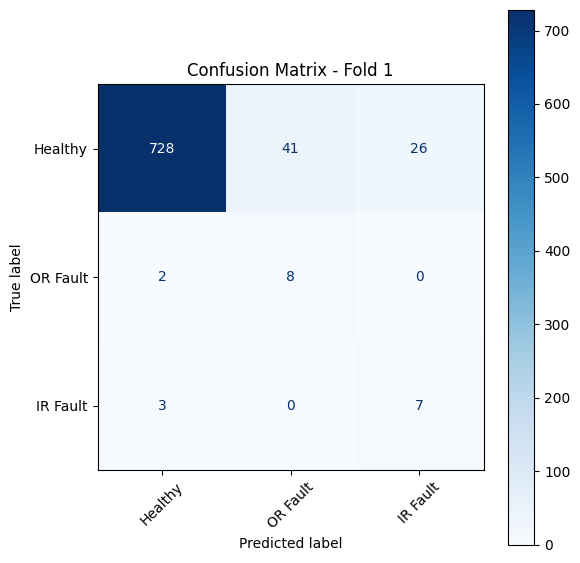

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 213ms/step - accuracy: 0.7771 - loss: 5.7173e-04 - val_accuracy: 0.8387 - val_loss: 0.0105
Epoch 131/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8278 - loss: 5.7501e-04
Epoch 131: val_accuracy did not improve from 0.83871
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.8276 - loss: 5.7587e-04 - val_accuracy: 0.7558 - val_loss: 0.0133
Epoch 132/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8062 - loss: 7.0292e-04
Epoch 132: val_accuracy did not improve from 0.83871
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.8061 - loss: 7.0269e-04 - val_accuracy: 0.7757 - val_loss: 0.0130
Epoch 133/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7900 - loss: 7.6238e-04
Epoch 133: val_accuracy did not improve from 0.83871
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.7899 - loss: 7.6068e-04 - val_accuracy: 0.8126 - val_loss: 0.0074
Epoch 134/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8187 

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.8304 - loss: 5.4099e-04 - val_accuracy: 0.8495 - val_loss: 0.0091
Epoch 136/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8087 - loss: 0.0011
Epoch 136: val_accuracy did not improve from 0.84946
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 0.8084 - loss: 0.0011 - val_accuracy: 0.7803 - val_loss: 0.0110
Epoch 137/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8269 - loss: 4.2169e-04
Epoch 137: val_accuracy improved from 0.84946 to 0.86022, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 0.8270 - loss: 4.2197e-04 - val_accuracy: 0.8602 - val_loss: 0.0110
Epoch 138/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8291 - loss: 4.5133e-04
Epoch 138: val_accuracy improved from 0.86022 to 0.89247, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.8292 - loss: 4.5135e-04 - val_accuracy: 0.8925 - val_loss: 0.0105
Epoch 139/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8647 - loss: 3.5841e-04
Epoch 139: val_accuracy improved from 0.89247 to 0.92780, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 19s 232ms/step - accuracy: 0.8648 - loss: 3.5802e-04 - val_accuracy: 0.9278 - val_loss: 0.0112
Epoch 140/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8864 - loss: 3.9054e-04
Epoch 140: val_accuracy did not improve from 0.92780
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.8863 - loss: 3.9057e-04 - val_accuracy: 0.9048 - val_loss: 0.0089
Epoch 141/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7922 - loss: 0.0067
Epoch 141: val_accuracy did not improve from 0.92780
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.7908 - loss: 0.0069 - val_accuracy: 0.2197 - val_loss: 0.0247
Epoch 142/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.2147 - loss: 0.1087
Epoch 142: val_accuracy did not improve from 0.92780
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.2137 - loss: 0.1081 - val_accuracy: 0.0154 - val_loss: 0.0236
Epoch 143/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.1785 - loss: 0.0254
E

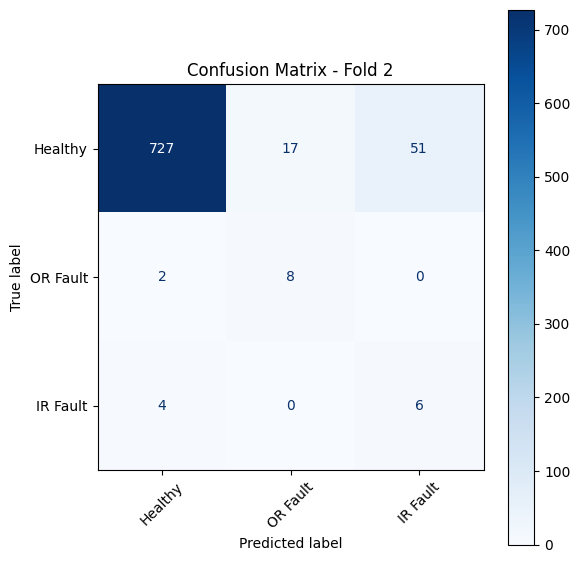

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_64 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.3275 - loss: 0.0026 - val_accuracy: 0.3978 - val_loss: 0.0030
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3573 - loss: 0.0017
Epoch 22: val_accuracy improved from 0.39785 to 0.41475, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.3578 - loss: 0.0016 - val_accuracy: 0.4147 - val_loss: 0.0027
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.3488 - loss: 0.0033
Epoch 23: val_accuracy did not improve from 0.41475
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.3485 - loss: 0.0033 - val_accuracy: 0.3886 - val_loss: 0.0037
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.3846 - loss: 0.0021
Epoch 24: val_accuracy improved from 0.41475 to 0.43164, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.3843 - loss: 0.0021 - val_accuracy: 0.4316 - val_loss: 0.0057
Epoch 25/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.4526 - loss: 0.0014
Epoch 25: val_accuracy improved from 0.43164 to 0.79263, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.4532 - loss: 0.0014 - val_accuracy: 0.7926 - val_loss: 0.0014
Epoch 26/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5880 - loss: 9.8010e-04
Epoch 26: val_accuracy improved from 0.79263 to 0.84025, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.5883 - loss: 9.7948e-04 - val_accuracy: 0.8402 - val_loss: 0.0012
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6814 - loss: 0.0021
Epoch 27: val_accuracy did not improve from 0.84025
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.6808 - loss: 0.0021 - val_accuracy: 0.0123 - val_loss: 0.1903
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.0264 - loss: 0.1745
Epoch 28: val_accuracy did not improve from 0.84025
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - accuracy: 0.0263 - loss: 0.1742 - val_accuracy: 0.0123 - val_loss: 0.0887
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.0196 - loss: 0.0918
Epoch 29: val_accuracy did not improve from 0.84025
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.0196 - loss: 0.0915 - val_accuracy: 0.0154 - val_loss: 0.0340
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.0236 - loss: 0.0601
Epoch 30: val_ac

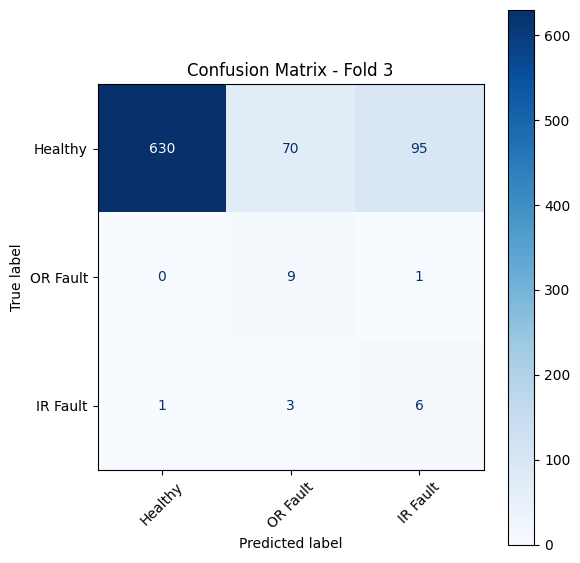

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_72 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.7386 - loss: 9.0543e-04 - val_accuracy: 0.7834 - val_loss: 0.0039
Epoch 34/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7531 - loss: 0.0011
Epoch 34: val_accuracy improved from 0.78341 to 0.85407, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.7531 - loss: 0.0011 - val_accuracy: 0.8541 - val_loss: 0.0046
Epoch 35/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.7369 - loss: 0.0014
Epoch 35: val_accuracy did not improve from 0.85407
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.7360 - loss: 0.0014 - val_accuracy: 0.7281 - val_loss: 0.0060
Epoch 36/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6782 - loss: 9.7389e-04
Epoch 36: val_accuracy did not improve from 0.85407
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.6782 - loss: 9.7353e-04 - val_accuracy: 0.7266 - val_loss: 0.0068
Epoch 37/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.7188 - loss: 0.0012
Epoch 37: val_accuracy did not improve from 0.85407
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.7189 - loss: 0.0012 - val_accuracy: 0.7127 - val_loss: 0.0060
Epoch 38/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7435 - loss: 8.0564e-04
Epoch 38

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.8763 - loss: 4.2901e-04 - val_accuracy: 0.8633 - val_loss: 0.0056
Epoch 42/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8794 - loss: 3.3483e-04
Epoch 42: val_accuracy improved from 0.86329 to 0.91705, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.8795 - loss: 3.3426e-04 - val_accuracy: 0.9171 - val_loss: 0.0065
Epoch 43/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7840 - loss: 0.0017
Epoch 43: val_accuracy did not improve from 0.91705
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.7833 - loss: 0.0017 - val_accuracy: 0.4424 - val_loss: 0.0107
Epoch 44/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6089 - loss: 0.0012
Epoch 44: val_accuracy did not improve from 0.91705
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.6093 - loss: 0.0012 - val_accuracy: 0.5038 - val_loss: 0.0072
Epoch 45/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7368 - loss: 9.1854e-04
Epoch 45: val_accuracy did not improve from 0.91705
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.7368 - loss: 9.1870e-04 - val_accuracy: 0.3456 - val_loss: 0.0125
Epoch 46/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7769 - loss: 7.0865e-04
Epoc

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.8663 - loss: 4.0929e-04 - val_accuracy: 0.9263 - val_loss: 0.0081
Epoch 85/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6884 - loss: 0.0619
Epoch 85: val_accuracy did not improve from 0.92627
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.6854 - loss: 0.0626 - val_accuracy: 0.0154 - val_loss: 0.1284
Epoch 86/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.0569 - loss: 0.1847
Epoch 86: val_accuracy did not improve from 0.92627
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.0566 - loss: 0.1836 - val_accuracy: 0.0184 - val_loss: 0.0673
Epoch 87/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.0227 - loss: 0.0632
Epoch 87: val_accuracy did not improve from 0.92627
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.0227 - loss: 0.0630 - val_accuracy: 0.0138 - val_loss: 0.0279
Epoch 88/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.0290 - loss: 0.0701
Epoch 88: val_ac

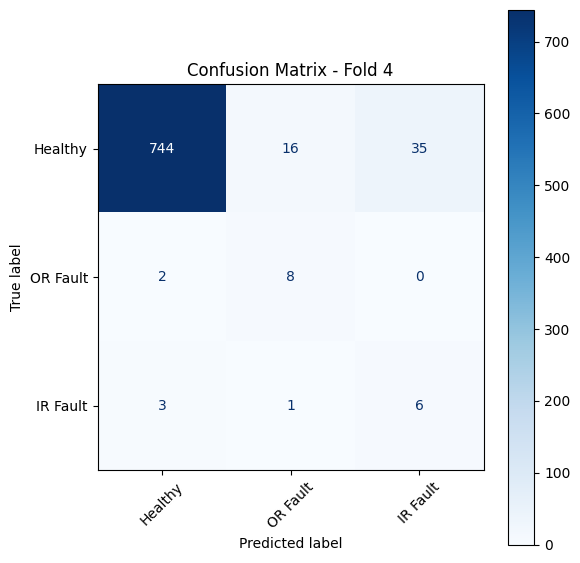

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_80 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.6086 - loss: 9.0844e-04 - val_accuracy: 0.7481 - val_loss: 0.0022
Epoch 25/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6777 - loss: 8.9421e-04
Epoch 25: val_accuracy did not improve from 0.74808
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.6780 - loss: 8.9305e-04 - val_accuracy: 0.7204 - val_loss: 0.0024
Epoch 26/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7060 - loss: 6.6395e-04
Epoch 26: val_accuracy improved from 0.74808 to 0.82181, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.7064 - loss: 6.6315e-04 - val_accuracy: 0.8218 - val_loss: 0.0025
Epoch 27/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7396 - loss: 6.7437e-04
Epoch 27: val_accuracy did not improve from 0.82181
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.7396 - loss: 6.7447e-04 - val_accuracy: 0.6283 - val_loss: 0.0029
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7645 - loss: 6.7610e-04
Epoch 28: val_accuracy did not improve from 0.82181
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.7644 - loss: 6.8654e-04 - val_accuracy: 0.0123 - val_loss: 0.1457
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.1928 - loss: 0.0468
Epoch 29: val_accuracy did not improve from 0.82181
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.1915 - loss: 0.0478 - val_accuracy: 0.0123 - val_loss: 0.1492
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0188 - loss: 0.1436
Epo

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.6197 - loss: 0.0012 - val_accuracy: 0.8418 - val_loss: 0.0027
Epoch 58/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6978 - loss: 0.0011
Epoch 58: val_accuracy improved from 0.84178 to 0.84793, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.6978 - loss: 0.0011 - val_accuracy: 0.8479 - val_loss: 0.0025
Epoch 59/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7457 - loss: 6.7666e-04
Epoch 59: val_accuracy improved from 0.84793 to 0.88326, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.7459 - loss: 6.7606e-04 - val_accuracy: 0.8833 - val_loss: 0.0024
Epoch 60/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6301 - loss: 0.0026
Epoch 60: val_accuracy did not improve from 0.88326
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.6280 - loss: 0.0026 - val_accuracy: 0.2504 - val_loss: 0.0151
Epoch 61/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.1555 - loss: 0.1381
Epoch 61: val_accuracy did not improve from 0.88326
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.1544 - loss: 0.1382 - val_accuracy: 0.0138 - val_loss: 0.1017
Epoch 62/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.0224 - loss: 0.0558
Epoch 62: val_accuracy did not improve from 0.88326
82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step - accuracy: 0.0223 - loss: 0.0558 - val_accuracy: 0.0184 - val_loss: 0.0570
Epoch 63/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.0238 - loss: 0.1132
Epoch 63: val_ac

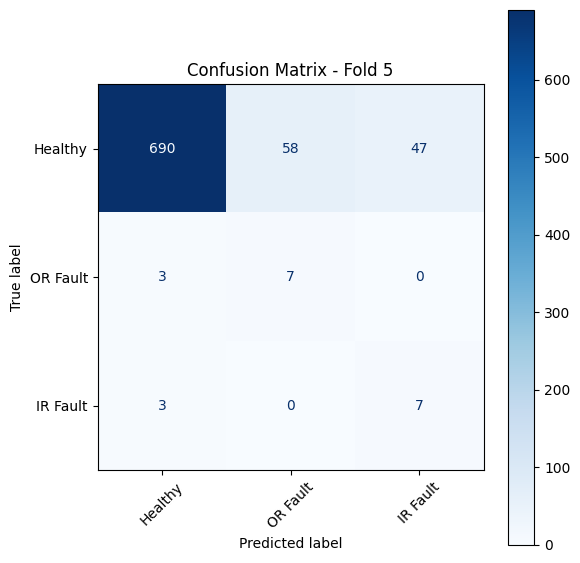

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 10315.46 seconds (171.92 minutes)


In [48]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-FL/"

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1,class_weight=class_weights)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [49]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 89.78%
Test Accuracy: 88.12%
Train Precision: 97.99%
Test Precision: 97.33%
Train Recall: 89.78%
Test Recall: 88.12%
Train F1: 92.96%
Test F1: 91.90%
Train Log Loss: 0.3944
Test Log Loss: 0.4210
Train Balanced Accuracy: 93.71%
Test Balanced Accuracy: 77.51%
Train Precision (Macro): 47.69%
Train Recall (Macro): 93.71%
Train F1 Score (Macro): 54.47%
Test Precision (Macro): 44.27%
Test Recall (Macro): 77.51%
Test F1 Score (Macro): 48.74%


102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step

 Classification Report - 2
              precision    recall  f1-score   support

     Healthy       1.00      0.88      0.94      3175
    OR Fault       0.15      1.00      0.26        40
    IR Fault       0.21      0.95      0.34        40

    accuracy                           0.88      3255
   macro avg       0.45      0.94      0.51      3255
weighted avg       0.98      0.88      0.92      3255



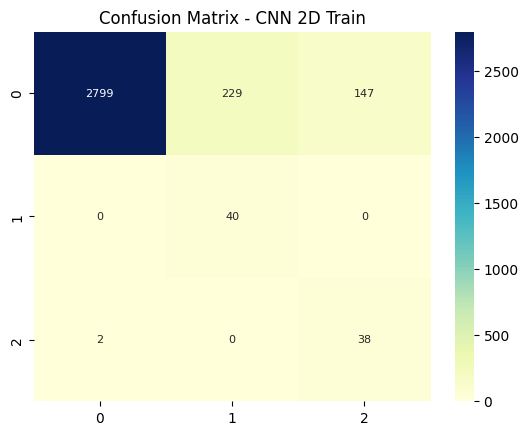

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

 Classification Report - 2
              precision    recall  f1-score   support

     Healthy       0.99      0.87      0.93       795
    OR Fault       0.11      0.70      0.19        10
    IR Fault       0.13      0.70      0.22        10

    accuracy                           0.86       815
   macro avg       0.41      0.76      0.44       815
weighted avg       0.97      0.86      0.91       815



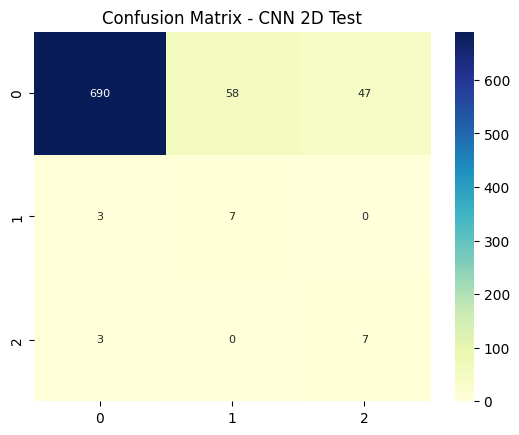

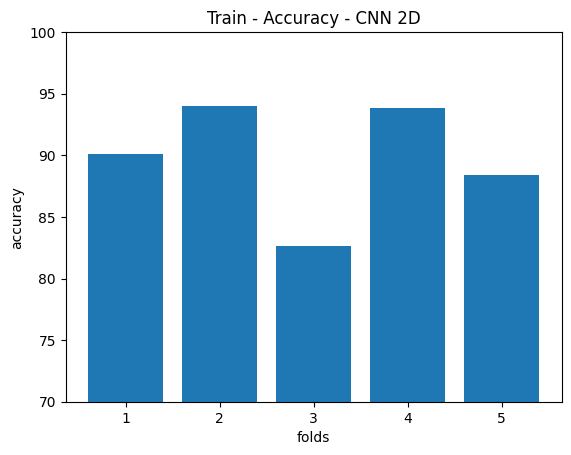

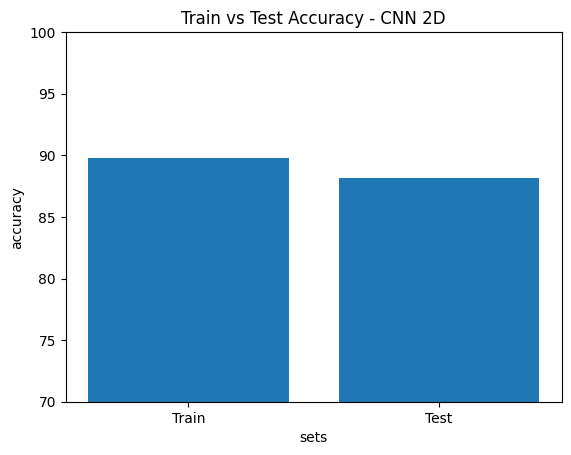

In [59]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    print(f"\n Classification Report - {label}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=2))
    return confusion_matrix(y_true, y_pred)

class_names = ['Healthy', 'OR Fault', 'IR Fault'] 

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()




In [66]:
# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_2D) * 100,
    'Test Accuracy (%)': np.array(accuracy_2D_test) * 100,

    'Train Precision (%)': np.array(precision_2D) * 100,
    'Test Precision (%)': np.array(precision_2D_test) * 100,

    'Train Recall (%)': np.array(recall_2D) * 100,
    'Test Recall (%)': np.array(recall_2D_test) * 100,

    'Train F1-score (%)': np.array(f1_2D) * 100,
    'Test F1-score (%)': np.array(f1_2D_test) * 100,

    'Train Precision-Macro (%)': np.array(precision_2D_macro) * 100,
    'Test Precision-Macro (%)': np.array(precision_2D_test_macro) * 100,

    'Train Recall-Macro (%)': np.array(recall_2D_macro) * 100,
    'Test Recall-Macro (%)': np.array(recall_2D_test_macro) * 100,

    'Train F1-score (%)': np.array(f1_2D_macro) * 100,
    'Test F1-score (%)': np.array(f1_2D_test_macro) * 100,

    'Train Log Loss': log_loss_2D,
    'Test Log Loss': log_loss_2D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_2D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_2D_test) * 100,
})

metrics_df.round(2)
# Sort by highest Test F1-score (%)
# sorted_df = metrics_df.sort_values(by='Test Balanced Accuracy (%)', ascending=False)
# sorted_df.round(2)

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Precision-Macro (%),Test Precision-Macro (%),Train Recall-Macro (%),Test Recall-Macro (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,90.08,91.17,98.02,97.34,90.08,91.17,54.40,51.65,47.30,45.62,95.79,80.52,0.41,0.41,95.79,80.52
1,2,93.98,90.92,98.15,97.27,93.98,90.92,61.47,52.93,52.55,47.24,93.01,77.15,0.25,0.30,93.01,77.15
2,3,82.61,79.14,97.85,97.60,82.61,79.14,44.82,39.55,41.63,38.90,94.06,76.42,0.56,0.61,94.06,76.42
3,4,93.86,93.01,98.00,97.47,93.86,93.01,60.53,55.21,51.85,48.66,91.32,77.86,0.27,0.29,91.32,77.86
4,5,88.39,86.38,97.91,97.00,88.39,86.38,51.11,44.37,45.11,40.96,94.39,75.60,0.48,0.50,94.39,75.60
